### Define the Generative Task and Select Approach

In the context of Logistics and Warehouse Automation, the ability to recognize a vast and ever-changing variety of products is a core challenge for robotic systems. Training robust vision models often requires massive amounts of labeled data, which is difficult to collect for rare or new inventory items. In this project, I implement a Variational Autoencoder (VAE) to explore synthetic data generation for warehouse items. By learning the underlying distribution of item shapes in a compressed latent space, this generative system can synthesize new, realistic item variations. This technology serves as a foundation for Data Augmentation in digital twins, enabling robots to "imagine" and learn from product variations they have not yet encountered in the physical world.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

/opt/anaconda3/envs/udacity-torch/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/udacity-torch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <5AA8DD3D-A2CC-31CA-8060-88B4E9C18B09> /opt/anaconda3/envs/udacity-torch/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <F33ACD4D-1C10-3F4E-ADEC-717A02BDBB52> /opt/anaconda3/envs/udacity-torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# Preprocessing definition (tensorization and normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalizing with MNIST's mean and standard deviation makes training more stable
    #transforms.Normalize((0.1307,), (0.3081,))
])

# Load the data (automatically downloaded if not present)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

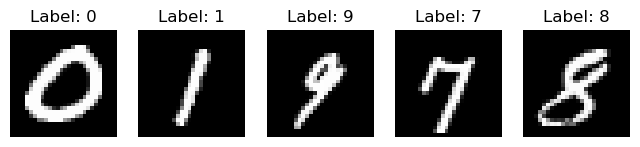

In [3]:
# Pick the first batch of data
images, labels = next(iter(train_loader))

# Display processing
plt.figure(figsize=(8, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Convert tensor to numpy and denormalize for display
    img = images[i].numpy().squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

In [4]:
print(images.shape) 
print(images.min(), images.max())

torch.Size([64, 1, 28, 28])
tensor(0.) tensor(1.)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # --- Encoder: Calculate statistics (mu, logvar) from image ---
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)    # 平均
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim) # 分散の対数
        
        # --- Decoder: Reconstruct image from latent variable z ---
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):   
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Calculate standard deviation
        std = torch.exp(0.5 * logvar)
        # Sample noise from standard normal distribution
        eps = torch.randn_like(std)
        # Sample latent variable using the reparameterization trick
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        # If MNIST pixel values are normalized to 0-1, limit output to 0-1 with Sigmoid
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        # 1. flatten (28x28 -> 784)
        mu, logvar = self.encode(x.view(-1, 784))
        # 2. Sample latent variable
        z = self.reparameterize(mu, logvar)
        # 3. Reconstruct image
        return self.decode(z), mu, logvar

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    # 1. Reconstruction Loss
    # How similar the input and reconstructed image are
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # 2. KL Divergence
    # How close the latent variable distribution is to the standard normal distribution (0, 1)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD

In [ ]:
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else "cpu")
# Create a VAE with a 2D latent space for easy visualization
model = VAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data)
        
        # Calculate loss
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')
    return train_loss / len(train_loader.dataset)

# 10〜20 epochs
losses = []
for epoch in range(1, 11):
    avg_loss = train(epoch)
    losses.append(avg_loss)

====> Epoch: 1 Average loss: 181.4877
====> Epoch: 2 Average loss: 163.9507
====> Epoch: 3 Average loss: 160.6114
====> Epoch: 4 Average loss: 158.5761
====> Epoch: 5 Average loss: 157.1692
====> Epoch: 6 Average loss: 156.0598
====> Epoch: 7 Average loss: 155.1893
====> Epoch: 8 Average loss: 154.3549
====> Epoch: 9 Average loss: 153.6329
====> Epoch: 10 Average loss: 153.0784


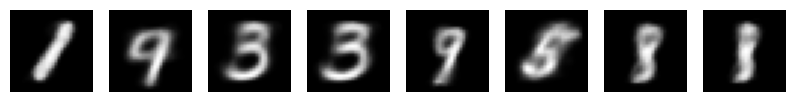

In [9]:
model.eval()
with torch.no_grad():
    # Sample from a 2D latent space (z_dim=2) following a standard normal distribution
    sample = torch.randn(64, 2).to(device)
    sample = model.decode(sample).cpu()
    
    # Display the first 8 samples
    plt.figure(figsize=(10, 2))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(sample[i].view(28, 28), cmap='gray')
        plt.axis('off')
    plt.show()

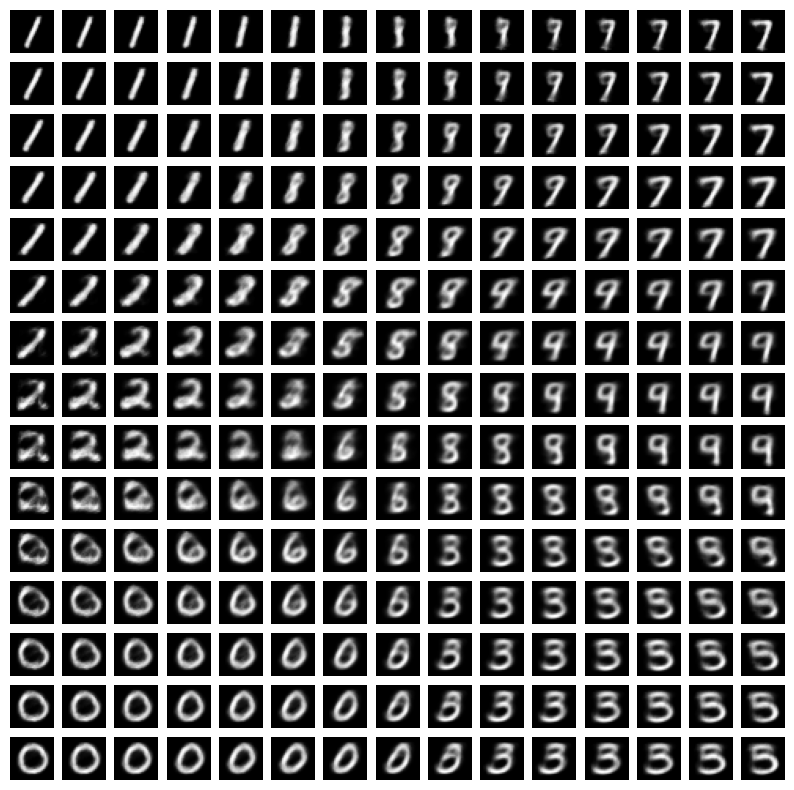

In [10]:
# Create a grid from -2 to 2 with 15 divisions
n = 15
grid_x = np.linspace(-2, 2, n)
grid_y = np.linspace(-2, 2, n)

plt.figure(figsize=(10, 10))
for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
        x_decoded = model.decode(z_sample).cpu().detach()
        digit = x_decoded[0].view(28, 28)
        plt.subplot(n, n, i * n + j + 1)
        plt.imshow(digit, cmap='gray')
        plt.axis('off')
plt.show()

### Summary

In this project, I implemented a Variational Autoencoder (VAE) to explore synthetic data generation, focusing on learning the latent representations of structural image data. The model successfully mapped high-dimensional inputs into a 2D latent space, enabling the generation of new samples and smooth interpolation between different classes. A primary challenge during training was balancing the reconstruction loss with the KL divergence term to prevent posterior collapse while ensuring the model captures meaningful geometric features. While the generated outputs effectively preserve the global structure of the input data, they exhibit the characteristic blurriness inherent in the VAE architecture compared to the original samples. These results demonstrate the potential of utilizing latent space exploration to create augmented datasets for perception systems in digital twin environments.